In [17]:
import yaml
import glob
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random

import random
from rdkit.Chem import Draw

from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Draw, AllChem
rdBase.DisableLog('rdApp.*')  # RDKitのエラーログを無効化
from rdkit.DataStructs import TanimotoSimilarity

from tdc import Evaluator as tdc_Evaluator

from mol_data import Mol_Data
from evaluator import Evaluator
from evaluator import population_similarity

In [18]:
class Island:

    smi2score = {}

    def __init__(self, path, task):
        self.evaluator = Evaluator(task)
        self.populations = []
        self.num_generation = 0

        self.load(path)

    def load(self,path):
        path = os.path.join(path,'population')
        # 指定されたディレクトリ内で'population_'で始まるすべてのYAMLファイルを検索します。
        yaml_files = glob.glob(os.path.join(path, 'population_*.yaml'))
        if yaml_files == []:
            print("No result files found in {}".format(path))
            return
        self.num_generation = len(yaml_files)

        def get_generation_number(filepath):
            """
            ファイル名から世代番号を抽出するためのヘルパー関数です。
            """
            filename = os.path.basename(filepath)
            # ファイル名の形式は 'population_{世代番号}G.yaml' を想定しています。
            try:
                # 世代番号の文字列を抽出し、整数に変換します。
                gen_str = filename.split('_')[1].replace('G.yaml', '')
                return int(gen_str)
            except (IndexError, ValueError):
                # ファイル名が期待される形式でない場合は-1を返します。
                return -1

        # 世代番号に基づいてYAMLファイルをソートし、時系列順に処理できるようにします。
        yaml_files.sort(key=get_generation_number)

        # ソートされたファイルリストをループ処理し、YAMLデータを読み込んで結果リストに追加します。
        print("Loading results ...")
        for yaml_file in tqdm(yaml_files):
            with open(yaml_file, 'r', encoding='utf-8') as f:
                datas = yaml.safe_load(f)
                population = []
                for data in datas.values():
                    
                    if data["smi"] not in Island.smi2score:
                        Island.smi2score[data["smi"]] = self.evaluator.score(data["smi"])

                    if "inter_smi" in data:
                        population.append(Mol_Data(
                            Chem.MolFromSmiles(data["smi"]),
                            data["smi"],
                            Island.smi2score[data["smi"]],
                            data["parent1_smi"],
                            data["parent2_smi"],
                            data["inter_smi"]))
                    if "inter_smi" not in data:
                        population.append(Mol_Data(
                            Chem.MolFromSmiles(data["smi"]),
                            data["smi"],
                            Island.smi2score[data["smi"]],
                            data["parent1_smi"],
                            data["parent2_smi"]))

                self.populations.append(population)

        print("Loading finished")

In [19]:
class visualizer:
    def __init__(self, islands):
        self.islands = islands
        self.diversity_evaluator = tdc_Evaluator(name="Diversity")

    def population_score(self,island):
        scores = []
        for population in island.populations:
            scores.append(np.mean([mlc.score for mlc in population]))
        return scores

    def plot_scoore_shift(self):
        avg_scores_dict = {name: self.population_score(island) for name, island in self.islands.items()}

        # Plot the avg_scores
        plt.figure(figsize=(10, 6))
        for name, scores in avg_scores_dict.items():
            plt.plot(scores, label=name)

        plt.xlabel("Oracle")
        plt.ylabel("Average Score")
        plt.title("Average Scores per Oracle for Each LLM")
        plt.legend()
        plt.show()

    def population_diversity(self,island):
        scores = []
        for population in island.populations:
            smis = [mlc.smi for mlc in population]
            scores.append(self.diversity_evaluator(smis))
        return scores

    def plot_diversity_shift(self):
        diversities_dict = {name: self.population_diversity(island) for name, island in self.islands.items()}
        # Plot the diversities
        plt.figure(figsize=(10, 6))
        for name, diversity_scores in diversities_dict.items():
            plt.plot(diversity_scores, label=name)

        plt.xlabel("Oracle")
        plt.ylabel("Diversity Score")
        plt.title("Diversity Scores per Oracle for Each LLM")
        plt.legend()
        plt.show()

    def plot_population_sim_matrix(self, generation):
        # Calculate the similarity matrix
        island_names = list(self.islands.keys())
        num_islands = len(island_names)
        similarity_matrix = np.zeros((num_islands, num_islands))

        for i in range(num_islands):
            for j in range(num_islands):
                if i <= j:  # Avoid redundant calculations
                    similarity = population_similarity(self.islands[island_names[i]].populations[generation], self.islands[island_names[j]].populations[generation])
                    similarity_matrix[i, j] = similarity
                    similarity_matrix[j, i] = similarity  # Symmetric matrix

        # Plot the similarity matrix as a heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(similarity_matrix, xticklabels=island_names, yticklabels=island_names, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("Population Similarity Matrix")
        plt.xlabel("Island")
        plt.ylabel("Island")
        plt.show()

In [20]:
random1 = visualizer({
    "Biot5": Island("results/forced_diversity_immigration/BioT5","JNK3"),
    "Gemma2:9B": Island("results/forced_diversity_immigration/Gemma","JNK3"),
    "Qwen3:8B": Island("results/forced_diversity_immigration/Qwen3","JNK3")
})

Found local copy...


Loading results ...


100%|██████████| 30/30 [00:22<00:00,  1.35it/s]
Found local copy...


Loading finished
Loading results ...


100%|██████████| 30/30 [00:19<00:00,  1.54it/s]
Found local copy...


Loading finished
Loading results ...


100%|██████████| 30/30 [00:13<00:00,  2.20it/s]

Loading finished


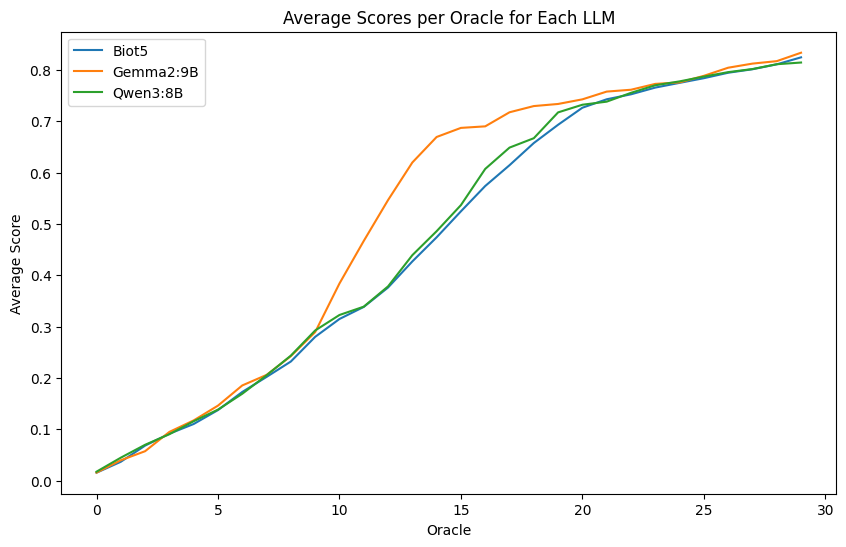

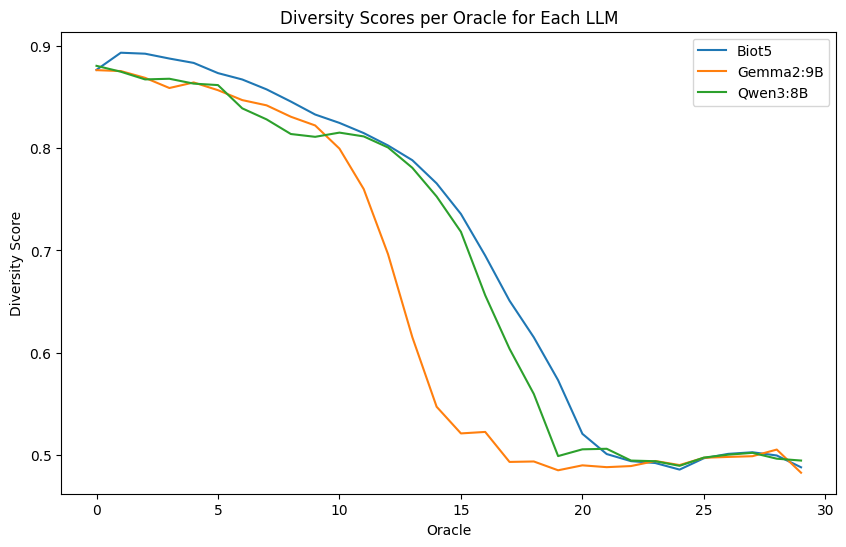

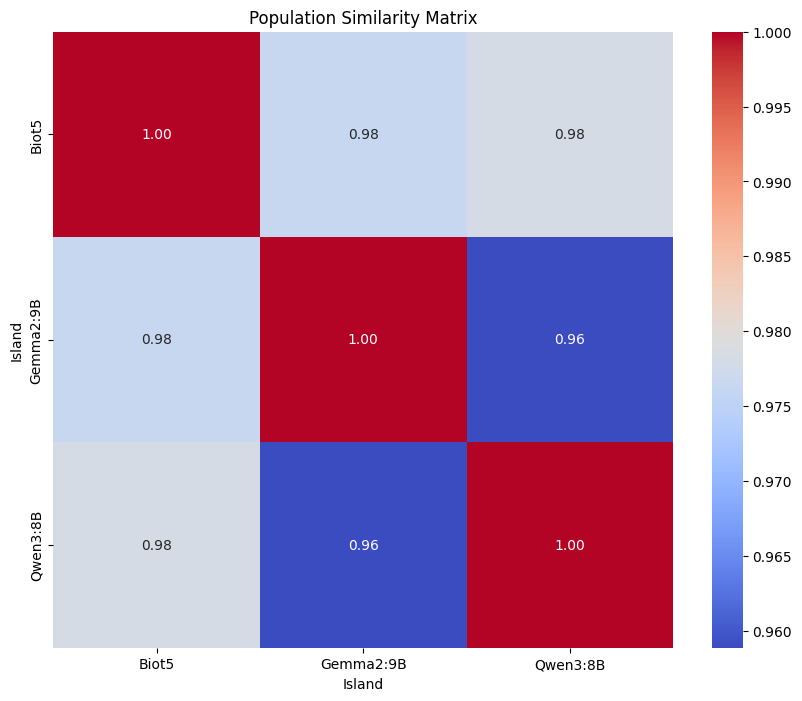

In [21]:
random1.plot_scoore_shift()
random1.plot_diversity_shift()
random1.plot_population_sim_matrix(generation=-1)